# Otimização Não Restrita — Gradiente Descendente

Notebook complementar à aula [CN09 — Otimização Não Restrita](../Aulas/CN09OtimizacaoNaoRestrita.qmd).

Implementa o método do gradiente descendente com **histórico completo** de iterações (1D e 2D),
ilustra o efeito do número de condição da Hessiana na convergência (zigue-zague), e compara
com o método de Newton e com `scipy.optimize.minimize`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Implementações (com histórico de iterações)

In [10]:
def gradiente_hist(grad_f, x0, alpha, n):
    """Gradiente descendente com passo fixo. Retorna o histórico de x_k (shape (n+1, dim))."""
    x = np.atleast_1d(np.asarray(x0, dtype=float))
    xs = [x.copy()]
    for _ in range(n):
        x = x - alpha * np.atleast_1d(grad_f(x))
        xs.append(x.copy())
    return np.array(xs)

In [11]:
def newton_1d_hist(df, ddf, x0, n):
    """Newton para otimização em 1D (zero de df usando ddf). Retorna o histórico de x_k."""
    x = float(x0)
    xs = [x]
    for _ in range(n):
        x = x - df(x) / ddf(x)
        xs.append(x)
    return np.array(xs)

## Exemplo 1D — mínimo de uma parábola

$$f(x) = (x-3)^2 + 1, \qquad f'(x) = 2(x-3), \qquad f''(x) = 2$$

Mínimo exato em $x^{*}=3$. Mesmo exemplo dos slides da aula.

In [12]:
f   = lambda x: (x - 3)**2 + 1
df  = lambda x: 2 * (x - 3)
ddf = lambda x: 2.0

N = 12
xs_grad   = gradiente_hist(df, x0=0.0, alpha=0.2, n=N).flatten()
xs_newton = newton_1d_hist(df, ddf, x0=0.0, n=N)

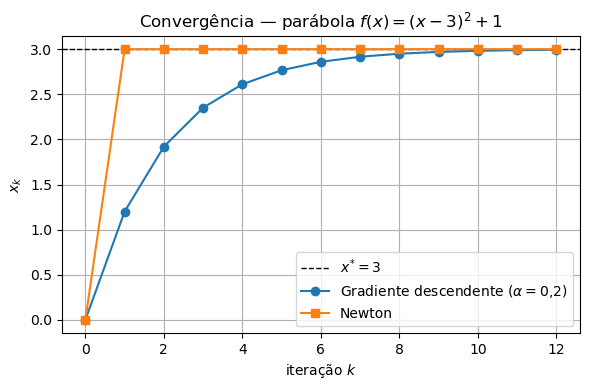

Gradiente: x_12 = 2.9934696530
Newton:    x_1 = 3.0000000000  (converge em 1 passo — f é quadrática)


In [13]:
plt.figure(figsize=(6, 4))
plt.axhline(3.0, color='k', linestyle='--', linewidth=1, label='$x^{*}=3$')
plt.plot(xs_grad, 'o-', label='Gradiente descendente ($\\alpha=0{,}2$)')
plt.plot(xs_newton, 's-', label='Newton')
plt.xlabel('iteração $k$')
plt.ylabel('$x_k$')
plt.title('Convergência — parábola $f(x)=(x-3)^2+1$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f'Gradiente: x_{N} = {xs_grad[-1]:.10f}')
print(f'Newton:    x_{1} = {xs_newton[1]:.10f}  (converge em 1 passo — f é quadrática)')

Newton converge em uma única iteração porque a curvatura $f''(x)$ é constante — o modelo
quadrático usado por Newton é **exato** para uma parábola. O gradiente descendente com passo
fixo $\alpha=0{,}2$ converge de forma geométrica, mais lenta.

## Exemplo 2D — paraboloide e número de condição

$$f(x,y) = x^2 + 10y^2, \qquad \nabla f(x,y) = (2x,\ 20y)$$

Hessiana $A=\operatorname{diag}(2,20)$, número de condição $\kappa = 20/2 = 10$ — fixo, não depende
do passo escolhido. Compara-se um passo moderado (decaimento suave em ambas as direções) com um
passo próximo do limite de estabilidade $\alpha < 2/\lambda_{\max}=0{,}1$, que faz a direção de
maior curvatura ($y$) **oscilar de sinal** a cada passo — o zigue-zague típico de Hessianas
mal-condicionadas.

In [14]:
f2d  = lambda v: v[0]**2 + 10 * v[1]**2
grad2d = lambda v: np.array([2 * v[0], 20 * v[1]])

x0 = [8.0, 1.0]
traj_suave = gradiente_hist(grad2d, x0, alpha=0.045, n=30)   # passo moderado
traj_zig   = gradiente_hist(grad2d, x0, alpha=0.095, n=30)   # passo próximo do limite de estabilidade

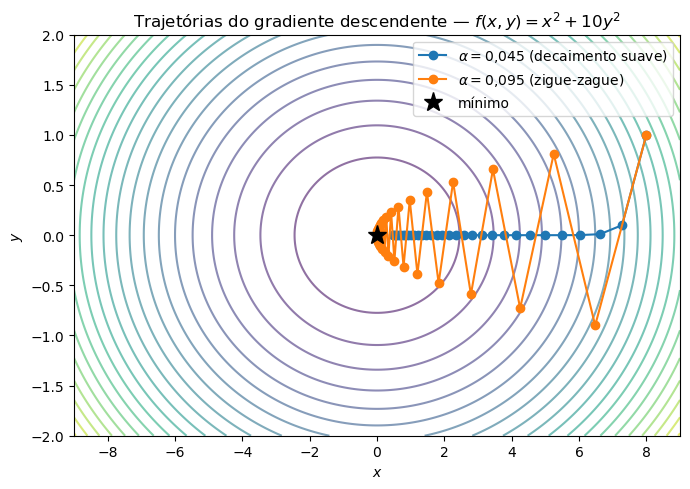

In [15]:
xg = np.linspace(-9, 9, 200)
yg = np.linspace(-2, 2, 200)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg**2 + 10 * Yg**2

plt.figure(figsize=(7, 5))
plt.contour(Xg, Yg, Zg, levels=20, cmap='viridis', alpha=0.6)
plt.plot(traj_suave[:, 0], traj_suave[:, 1], 'o-', label='$\\alpha=0{,}045$ (decaimento suave)')
plt.plot(traj_zig[:, 0], traj_zig[:, 1], 'o-', label='$\\alpha=0{,}095$ (zigue-zague)')
plt.plot(0, 0, 'k*', markersize=14, label='mínimo')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Trajetórias do gradiente descendente — $f(x,y)=x^2+10y^2$')
plt.legend()
plt.tight_layout()
plt.show()

## Comparação com o SciPy

In [16]:
from scipy.optimize import minimize

res = minimize(f2d, x0=x0, jac=grad2d, method='BFGS')
print('BFGS  :', res.x, ' iterações:', res.nit)
print('Gradiente (alpha=0.045):', traj_bom[-1], ' iterações:', len(traj_bom) - 1)

BFGS  : [ 9.16336424e-07 -3.68883693e-08]  iterações: 5
Gradiente (alpha=0.045): [4.72423787e-01 1.00000000e-30]  iterações: 30
